# __Hometask__

1. Load the **Electricity Consumption data** in Romania (`./datasets/electricity_consumption_and_production.csv`). Use the `Consumption` column as the target variable.
2. Perform **EDA**: decompose the series, plot ACF and PACF, and run the ADF stationarity test. Note that the data contains **hourly observations** — resample to daily before performing forecast.
3. Clean data if necessary.
4. Train forecasting models (Use models from the lecture or other ones if you wish) and produce forecasts for **15, 30, and 45 days ahead**.
5. Visualize predictions and provide evaluation metrics

#### Download dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# For create model
import xgboost 
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler

# For output metricks
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# For perform EDA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

import warnings
warnings.filterwarnings('ignore')

### 1. Load the **Electricity Consumption data** in Romania

In [2]:
fp = './datasets/electricity_consumption_and_production.csv'
df = pd.read_csv(fp, parse_dates=['DateTime'], index_col ='DateTime')

y = df['Consumption'] 

print(f'Dataset Shape: {y.shape}') 

y.sample(5)

Dataset Shape: (54161,)


DateTime
2020-10-04 05:00:00    4970
2019-11-26 09:00:00    8517
2023-03-28 05:00:00    5637
2022-04-25 12:00:00    4822
2024-09-08 23:00:00    5215
Name: Consumption, dtype: int64

### 2. Perform **EDA**:

#### Preprocessing 

In [3]:
def preprocess_timeseries(series: pd.Series, freq: str = 'D', resample_to: str = 'MS') -> pd.Series:
 
    # Drop duplicates
    series = series[~series.index.duplicated(keep='first')]
     
    # Fill missing data
    full_range = pd.date_range(
        start=series.index.min(), 
        end=series.index.max(), 
        freq=freq
    )
    series = series.reindex(full_range)
    
    # illing in gaps using linear interpolation
    missing_before = series.isna().sum()
    series = series.interpolate(method='linear')
    
    series = series.ffill().bfill()
    missing_after = series.isna().sum()
     
    # resampling date
    if resample_to == 'MS':  
        resampled = series.resample('MS').mean()
    elif resample_to == 'D': 
        resampled = series.resample('D').mean()
    else:
        resampled = series.resample(resample_to).mean()
    
    return resampled
 
  
# Gets resampling date
daily_consumption = preprocess_timeseries(
    y, 
    freq='D',      
    resample_to='D'  
)
monthly_consumption = preprocess_timeseries(
    y,
    freq='D',
    resample_to='MS'
)
 

#### Seasonal Decomposition

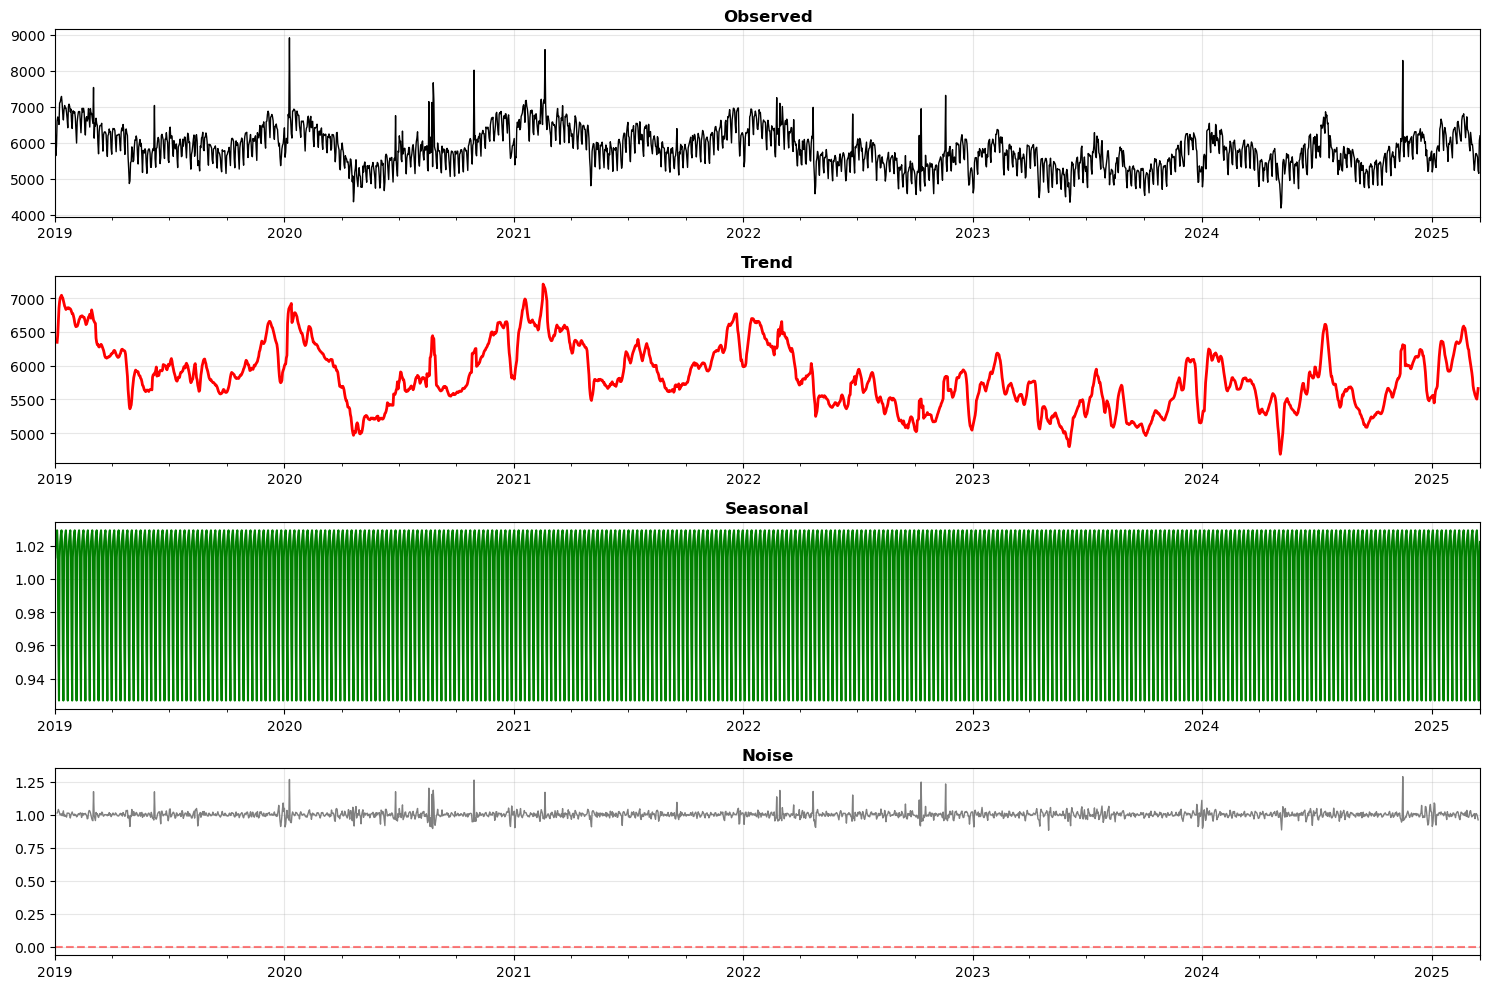

In [4]:
 
decomposition = seasonal_decompose(
    daily_consumption, 
    model='multiplicative',  
    period = 7
)
 
fig, axes = plt.subplots(4, 1, figsize=(15, 10)) 

decomposition.observed.plot(ax=axes[0], color='black', linewidth=1)
axes[0].set_title('Observed', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

decomposition.trend.plot(ax=axes[1], color='red', linewidth=2)
axes[1].set_title("Trend", fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

decomposition.seasonal.plot(ax=axes[2], color='green', linewidth=1.5)
axes[2].set_title('Seasonal', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

decomposition.resid.plot(ax=axes[3], color='gray', linewidth=1)
axes[3].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[3].set_title('Noise', fontsize=12, fontweight='bold')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show() 

#### Seasonal Patterns by Month and Season

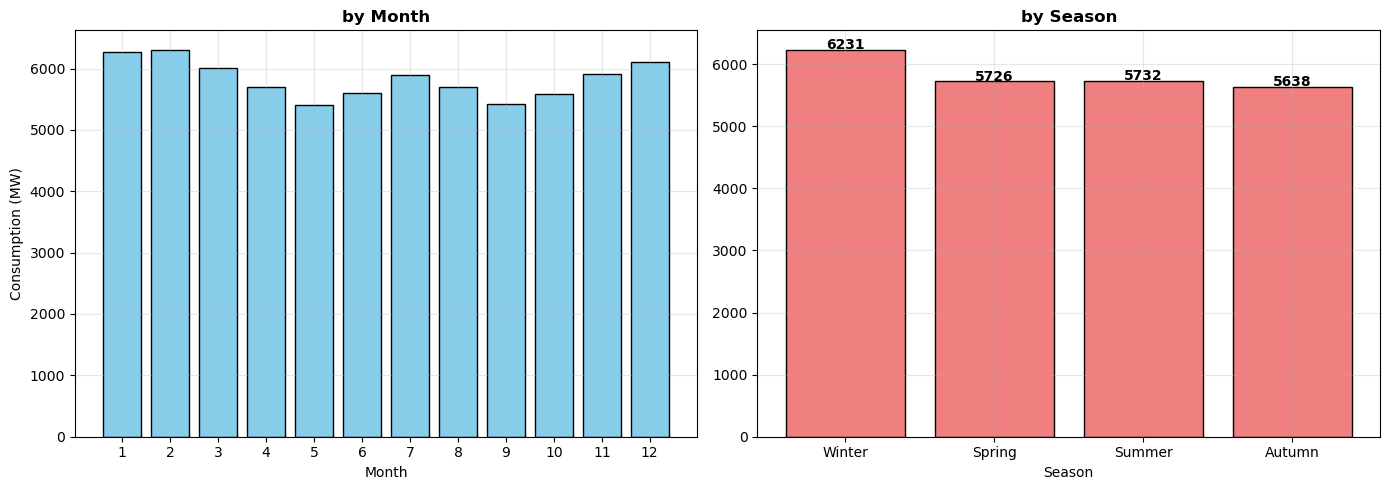

In [5]:
 
SEASONS = {
    "Winter": [12, 1, 2],    
    "Spring": [3, 4, 5],    
    "Summer": [6, 7, 8],     
    "Autumn": [9, 10, 11]   
}
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
monthly_avg = monthly_consumption.groupby(monthly_consumption.index.month).mean()
axes[0].bar(monthly_avg.index, monthly_avg.values, color="skyblue", edgecolor='black')
axes[0].set_title("by Month", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Month", fontsize=10)
axes[0].set_ylabel("Consumption (MW)", fontsize=10)
axes[0].set_xticks(range(1, 13)) 
axes[0].grid(True, alpha=0.3)
 
seasonal_avg = {
    season: monthly_consumption[monthly_consumption.index.month.isin(months)].mean()
    for season, months in SEASONS.items()
}

axes[1].bar(seasonal_avg.keys(), seasonal_avg.values(), color="lightcoral", edgecolor='black')
axes[1].set_title("by Season", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Season", fontsize=10) 
axes[1].grid(True, alpha=0.3)
 
for i, (season, value) in enumerate(seasonal_avg.items()):
    axes[1].text(i, value + 5, f'{value:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

#### Autocorrelation & Partial Autocorrelation

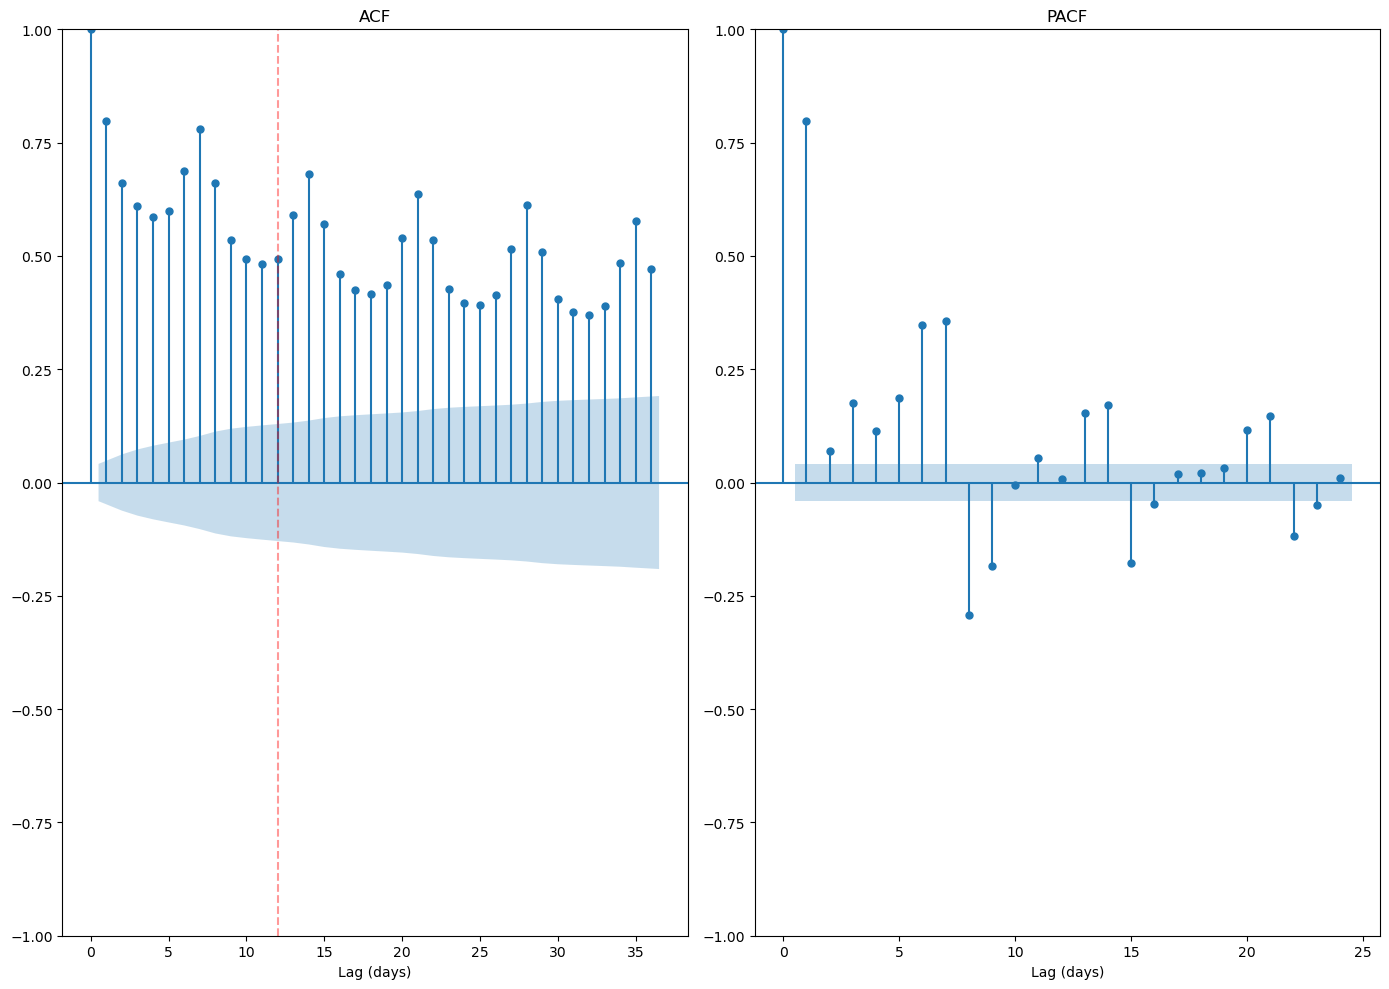

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 10))

plot_acf(daily_consumption, lags=36, ax=axes[0], title="ACF")
axes[0].axvline(x=12, color="red", linestyle="--", alpha=0.4)
axes[0].set_xlabel("Lag (days)")

plot_pacf(daily_consumption, lags=24, ax = axes[1], method="ywm", title="PACF")
axes[1].set_xlabel("Lag (days)")

plt.tight_layout()
plt.show()

#### ADF stationarity test

In [7]:
def adf_stationarity_test(series):
    result = adfuller(series)
    p_value = result[1]
    print(f"ADF Statistic {round(result[0], 4)},\np-value {round(p_value, 4)},\nStationary {p_value < 0.05}")
adf_result = adf_stationarity_test(daily_consumption.dropna())


ADF Statistic -3.4104,
p-value 0.0106,
Stationary True


#### Making a Non-Stationary Series Stationary: Differencing

ADF Statistic -3.4104,
p-value 0.0106,
Stationary True
ADF Statistic -12.3181,
p-value 0.0,
Stationary True


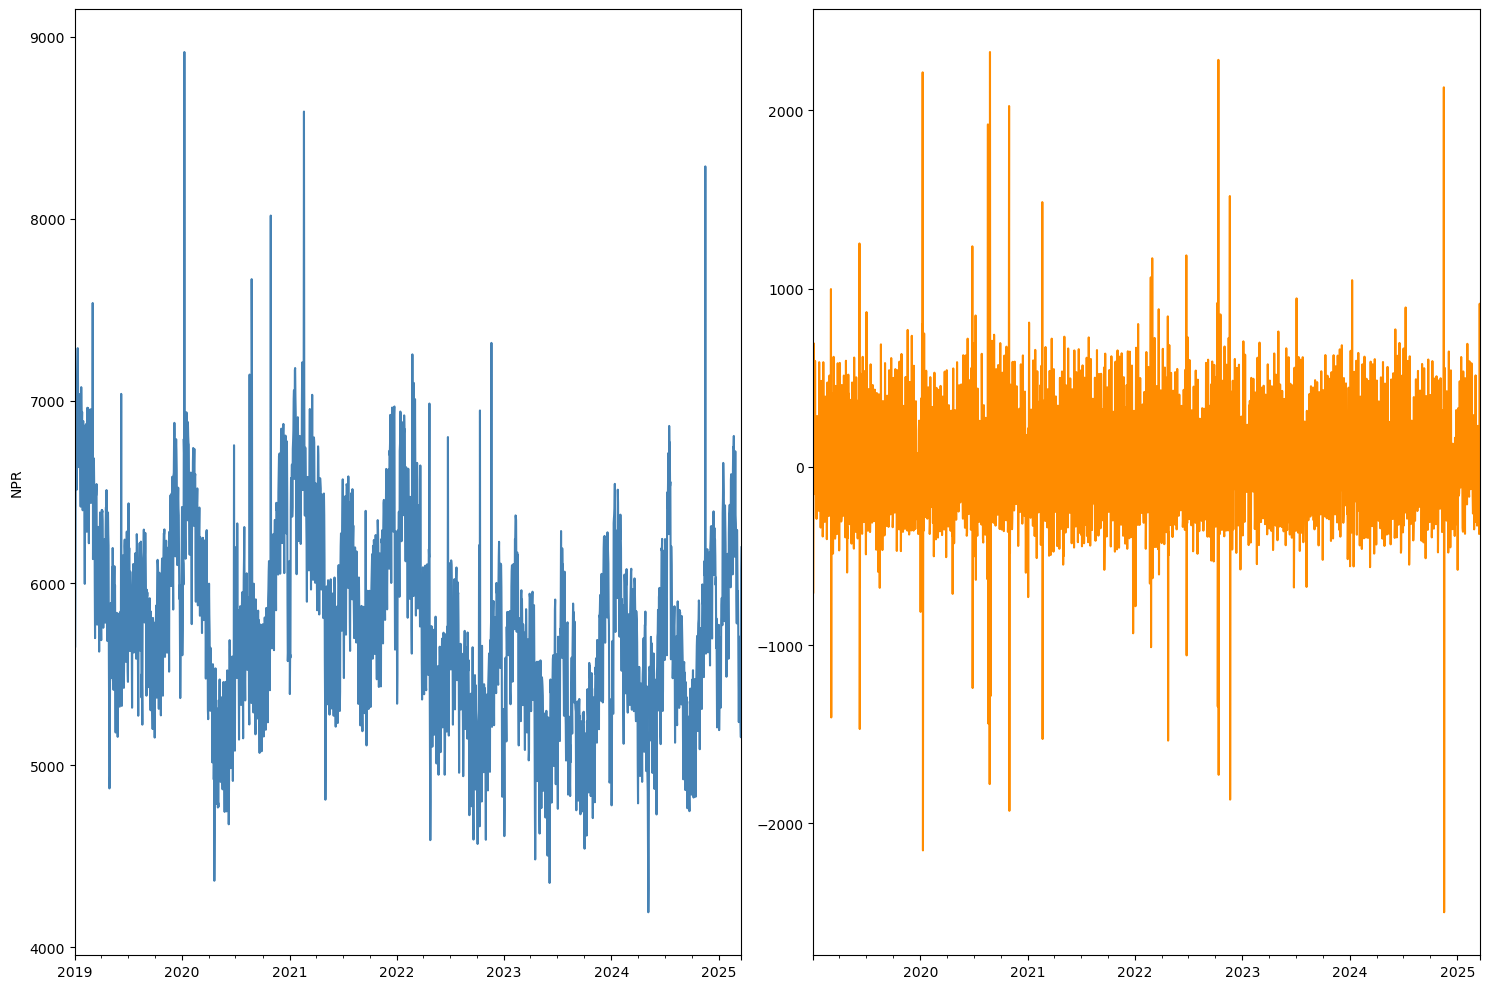

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 10))

differenced = daily_consumption.diff().dropna()
adf_orig = adf_stationarity_test(daily_consumption)
adf_diff = adf_stationarity_test(differenced)

daily_consumption.plot(ax = axes[0], color = "steelblue")
axes[0].set_title(adf_orig, fontsize=9)
axes[0].set_ylabel("NPR")

differenced.plot(ax = axes[1], color = "darkorange")
axes[1].set_title(adf_diff, fontsize=9)

plt.tight_layout()
plt.show()

### 3. Train forecasting models

#### Func for output metrick

In [9]:
def evaluate_forecast(y_true, y_pred, horizon_name=""): 
    
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    print(f"\n {horizon_name}:")
    print(f"   MAPE: {mape:.2f}%")
    print(f"   MAE:  {mae:.2f} MW")
    print(f"   RMSE: {rmse:.2f} MW")
    
    return {'MAPE': mape, 'MAE': mae, 'RMSE': rmse}
 

#### Model 1: Naive

In [10]:
def naive_forecast(series, horizon):  
    last_value = series.iloc[-1]
    forecast = pd.Series([last_value] * horizon, 
                         index=pd.date_range(series.index[-1] + pd.Timedelta(days=1), 
                                           periods=horizon, freq='D'))
    return forecast
 
# save result for naive model 
naive_results = {}

for horizon in [15, 30, 45]: 
    
    train = daily_consumption[:-horizon]
    test = daily_consumption[-horizon:]
     
    forecast = naive_forecast(train, horizon)
     
    metrics = evaluate_forecast(test, forecast, f"Naive {horizon} днів")
    naive_results[horizon] = {'forecast': forecast, 'metrics': metrics}




 Naive 15 днів:
   MAPE: 11.06%
   MAE:  608.57 MW
   RMSE: 687.96 MW

 Naive 30 днів:
   MAPE: 6.82%
   MAE:  406.33 MW
   RMSE: 478.80 MW

 Naive 45 днів:
   MAPE: 7.43%
   MAE:  463.89 MW
   RMSE: 535.25 MW


#### Model 2: SARIMA

In [11]:
def sarima_forecast(train, horizon):   
    model = SARIMAX(train, 
                    order=(1, 1, 1),      
                    seasonal_order=(1, 1, 1, 7),   
                    enforce_stationarity=False,
                    enforce_invertibility=False)
    
    fitted_model = model.fit(disp=False)
    forecast = fitted_model.forecast(steps=horizon)
     
    forecast_index = pd.date_range(train.index[-1] + pd.Timedelta(days=1), 
                                   periods=horizon, freq='D')
    forecast_series = pd.Series(forecast.values, index=forecast_index)
    
    return forecast_series
 
# save result for sarima model 
sarima_results = {}

for horizon in [15, 30, 45]: 
     
    train = daily_consumption[:-horizon]
    test = daily_consumption[-horizon:]
     
    forecast = sarima_forecast(train, horizon)
     
    metrics = evaluate_forecast(test, forecast, f"SARIMA {horizon} днів")
    sarima_results[horizon] = {'forecast': forecast, 'metrics': metrics}


 SARIMA 15 днів:
   MAPE: 9.49%
   MAE:  529.02 MW
   RMSE: 565.65 MW

 SARIMA 30 днів:
   MAPE: 7.65%
   MAE:  440.54 MW
   RMSE: 526.46 MW

 SARIMA 45 днів:
   MAPE: 5.88%
   MAE:  360.66 MW
   RMSE: 404.01 MW


#### Model 3: PROPHET

In [12]:


def prophet_forecast(train, horizon):  
    train_df = pd.DataFrame({
        'ds': train.index,
        'y': train.values
    })
     
    model = Prophet(
        yearly_seasonality=True,   
        weekly_seasonality=True,   
        daily_seasonality=False,  
        changepoint_prior_scale=0.05
    )
     
    model.fit(train_df)
     
    future = model.make_future_dataframe(periods=horizon, include_history=False)
     
    forecast = model.predict(future)
     
    forecast_series = pd.Series(forecast['yhat'].values, index=future['ds'])
    
    return forecast_series

# save result for prophet model 
prophet_results = {}

for horizon in [15, 30, 45]: 
     
    train = daily_consumption[:-horizon]
    test = daily_consumption[-horizon:]
     
    forecast = prophet_forecast(train, horizon)
     
    metrics = evaluate_forecast(test, forecast, f"Prophet {horizon} днів")
    prophet_results[horizon] = {'forecast': forecast, 'metrics': metrics}

19:41:59 - cmdstanpy - INFO - Chain [1] start processing
19:42:00 - cmdstanpy - INFO - Chain [1] done processing
19:42:00 - cmdstanpy - INFO - Chain [1] start processing



 Prophet 15 днів:
   MAPE: 6.73%
   MAE:  376.54 MW
   RMSE: 401.20 MW


19:42:00 - cmdstanpy - INFO - Chain [1] done processing
19:42:00 - cmdstanpy - INFO - Chain [1] start processing



 Prophet 30 днів:
   MAPE: 5.03%
   MAE:  298.52 MW
   RMSE: 340.63 MW


19:42:01 - cmdstanpy - INFO - Chain [1] done processing



 Prophet 45 днів:
   MAPE: 4.34%
   MAE:  261.67 MW
   RMSE: 308.13 MW


#### Model 4: XGBOOST

In [13]:


def create_lag_features(series, n_lags=7): 
    df = pd.DataFrame(series)
    df.columns = ['target']
     
    for lag in range(1, n_lags + 1):
        df[f'lag_{lag}'] = df['target'].shift(lag)
     
    for window in [3, 7]:
        df[f'rolling_mean_{window}'] = df['target'].rolling(window).mean()
        df[f'rolling_std_{window}'] = df['target'].rolling(window).std()
     
    df['day_of_week'] = df.index.dayofweek
    df['month'] = df.index.month
    df['day_of_year'] = df.index.dayofyear
     
    df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    
    return df.dropna()


In [14]:
def xgboost_forecast(train_series, horizon, n_lags=7):  
     
    train_features = create_lag_features(train_series, n_lags)
    
    X_train = train_features.drop('target', axis=1)
    y_train = train_features['target']
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    
    model = XGBRegressor(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    
    predictions = []
    
    last_values = train_series.values[-n_lags:].tolist()
    last_dates = train_series.index[-n_lags:].tolist()
    
    for i in range(horizon):
        current_features = {}
        
        for lag in range(1, n_lags + 1):
            if lag <= len(last_values):
                current_features[f'lag_{lag}'] = last_values[-lag]
            else:
                current_features[f'lag_{lag}'] = last_values[0]
        
        window_3 = last_values[-3:] if len(last_values) >= 3 else last_values
        window_7 = last_values[-7:] if len(last_values) >= 7 else last_values
        
        current_features['rolling_mean_3'] = np.mean(window_3)
        current_features['rolling_std_3'] = np.std(window_3)
        current_features['rolling_mean_7'] = np.mean(window_7)
        current_features['rolling_std_7'] = np.std(window_7)
        
        next_date = train_series.index[-1] + pd.Timedelta(days=i+1)
        current_features['day_of_week'] = next_date.dayofweek
        current_features['month'] = next_date.month
        current_features['day_of_year'] = next_date.dayofyear
        current_features['dow_sin'] = np.sin(2 * np.pi * next_date.dayofweek / 7)
        current_features['dow_cos'] = np.cos(2 * np.pi * next_date.dayofweek / 7)
        
        features_df = pd.DataFrame([current_features])
        
        features_df = features_df[X_train.columns]
        
        features_scaled = scaler.transform(features_df)
        
        pred = model.predict(features_scaled)[0]
        predictions.append(pred)
        
        last_values.append(pred)
        if len(last_values) > n_lags * 2:
            last_values = last_values[-n_lags:]
    
    forecast_index = pd.date_range(
        start=train_series.index[-1] + pd.Timedelta(days=1),
        periods=horizon,
        freq='D'
    )
    forecast_series = pd.Series(predictions, index=forecast_index)
    
    return forecast_series

In [15]:
# save result for xgboost model 
xgboost_results = {}

for horizon in [15, 30, 45]: 
     
    train = daily_consumption[:-horizon]
    test = daily_consumption[-horizon:]
     
    try:
        forecast = xgboost_forecast(train, horizon)
         
        metrics = evaluate_forecast(test, forecast, f"XGBoost {horizon} днів")
        xgboost_results[horizon] = {'forecast': forecast, 'metrics': metrics}
    except Exception as e:
        print(f"Помилка при навчанні XGBoost: {e}")


 XGBoost 15 днів:
   MAPE: 7.25%
   MAE:  396.18 MW
   RMSE: 479.88 MW

 XGBoost 30 днів:
   MAPE: 7.30%
   MAE:  422.24 MW
   RMSE: 509.94 MW

 XGBoost 45 днів:
   MAPE: 5.69%
   MAE:  340.47 MW
   RMSE: 409.83 MW


### 4. Visualize predictions and provide evaluation metrics

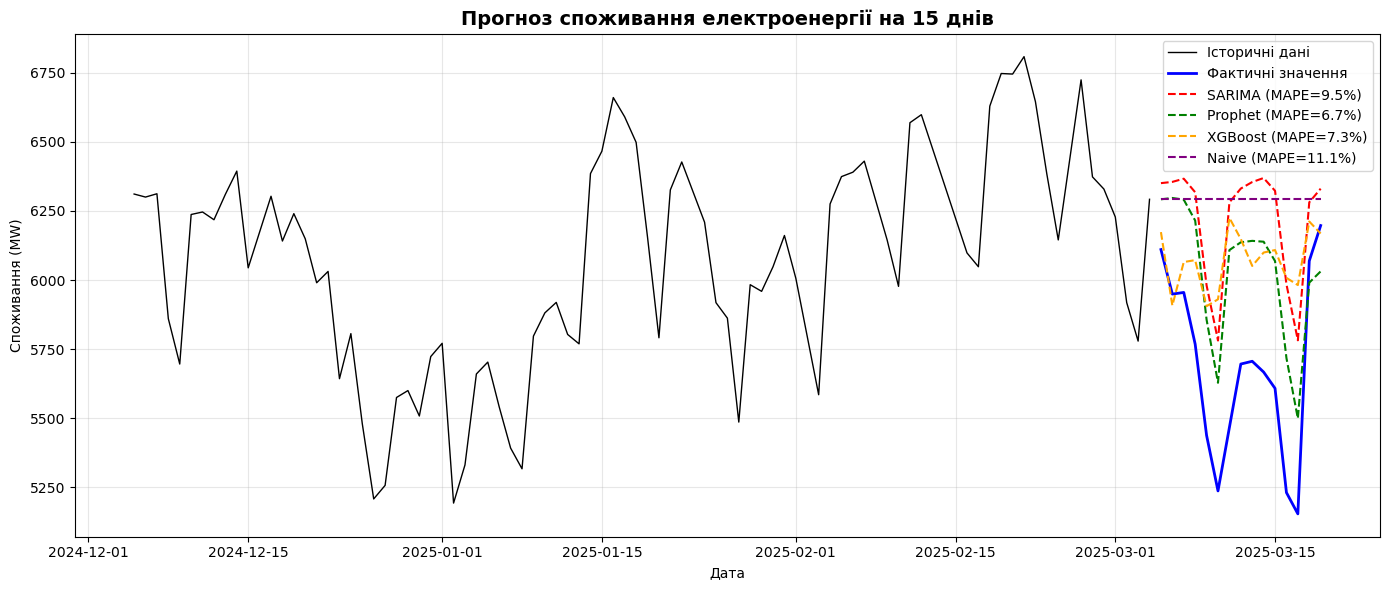

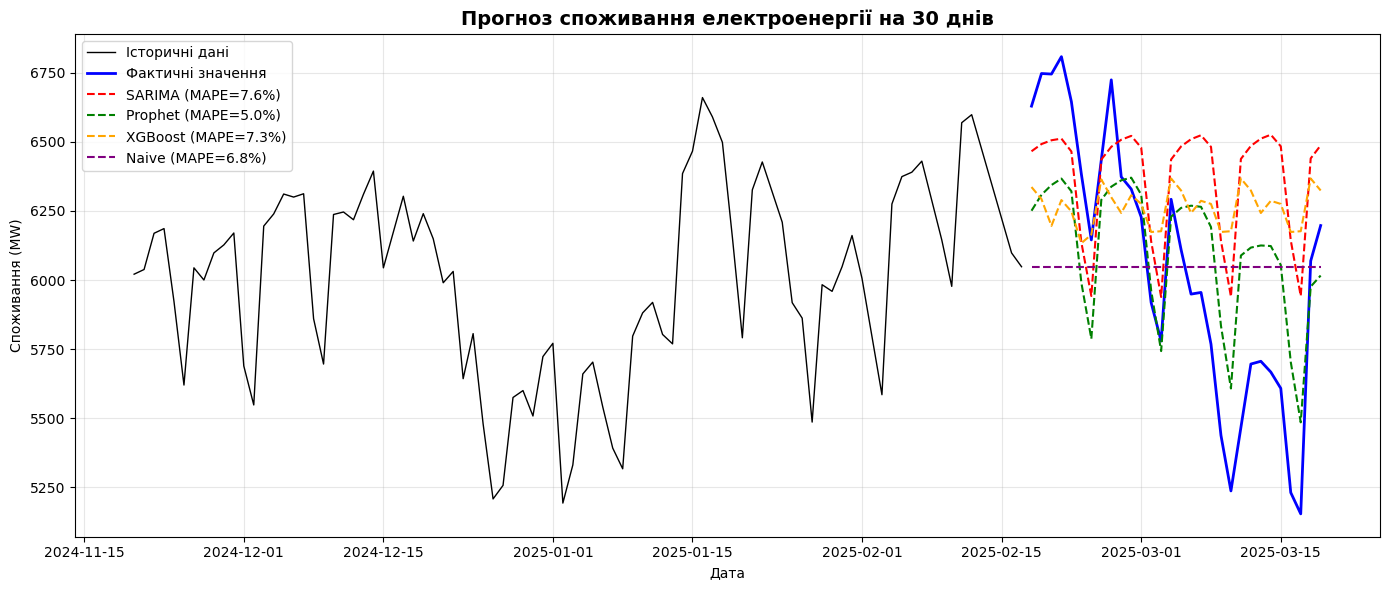

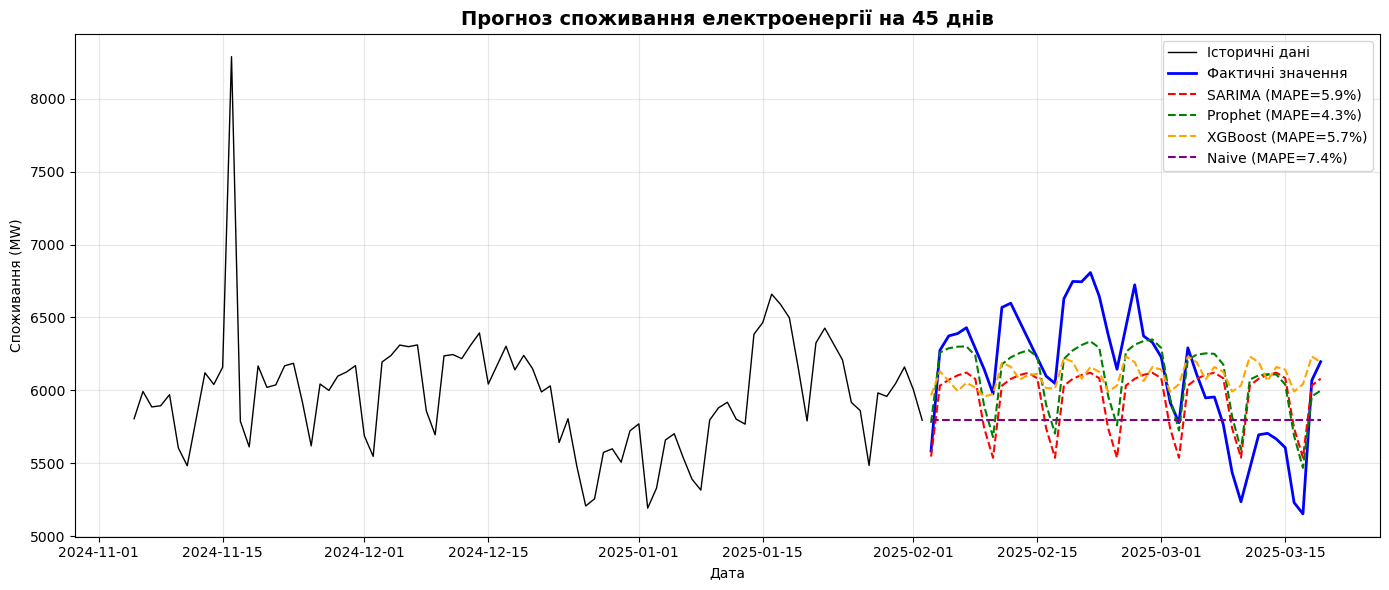

In [16]:
all_results = {
    'SARIMA': sarima_results,
    'Prophet': prophet_results,
    'XGBoost': xgboost_results,
    'Naive': naive_results
}

def plot_horizon_results(horizon, results_dict, daily_data):
    """
    Візуалізація прогнозів для конкретного горизонту
    """
    fig, ax = plt.subplots(figsize=(14, 6))
     
    train = daily_data[:-horizon]
    test = daily_data[-horizon:]
     
    ax.plot(train.index[-90:], train.values[-90:], 
           label='Історичні дані', color='black', linewidth=1)
     
    ax.plot(test.index, test.values, 
           label='Фактичні значення', color='blue', linewidth=2)
     
    colors = {'SARIMA': 'red', 'Prophet': 'green', 'XGBoost': 'orange'}
    
    for model_name, results in results_dict.items():
        if horizon in results:
            forecast = results[horizon]['forecast']
            metrics = results[horizon]['metrics']
            ax.plot(forecast.index, forecast.values, 
                   label=f"{model_name} (MAPE={metrics['MAPE']:.1f}%)", 
                   color=colors.get(model_name, 'purple'), 
                   linestyle='--', linewidth=1.5)
    
    ax.set_title(f'Прогноз споживання електроенергії на {horizon} днів', 
                fontsize=14, fontweight='bold')
    ax.set_xlabel('Дата')
    ax.set_ylabel('Споживання (MW)')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
 
for horizon in [15, 30, 45]:
    plot_horizon_results(horizon, all_results, daily_consumption)

#### evaluation metrics for all models 

In [17]:
def create_summary_table(results_dict, horizons):
    summary = [] 
    for model_name, results in results_dict.items():
        for horizon in horizons:
            if horizon in results:
                metrics = results[horizon]['metrics']
                summary.append({
                    'Model': model_name,
                    'Horizon (day)': horizon,
                    'MAPE (%)': round(metrics['MAPE'], 2),
                    'MAE (MW)': round(metrics['MAE'], 2),
                    'RMSE (MW)': round(metrics['RMSE'], 2)
                })  
    summary_df = pd.DataFrame(summary)
    summary_df = summary_df.sort_values(['Horizon (day)', 'MAPE (%)'])
    
    return summary_df

horizons = [15, 30, 45]
summary_table = create_summary_table(all_results, horizons)
 
# Output table with all result
print(summary_table.to_string(index=False))
 

  Model  Horizon (day)  MAPE (%)  MAE (MW)  RMSE (MW)
Prophet             15      6.73    376.54     401.20
XGBoost             15      7.25    396.18     479.88
 SARIMA             15      9.49    529.02     565.65
  Naive             15     11.06    608.57     687.96
Prophet             30      5.03    298.52     340.63
  Naive             30      6.82    406.33     478.80
XGBoost             30      7.30    422.24     509.94
 SARIMA             30      7.65    440.54     526.46
Prophet             45      4.34    261.67     308.13
XGBoost             45      5.69    340.47     409.83
 SARIMA             45      5.88    360.66     404.01
  Naive             45      7.43    463.89     535.25
